In [41]:
import numpy as np
import matplotlib.pyplot as plt

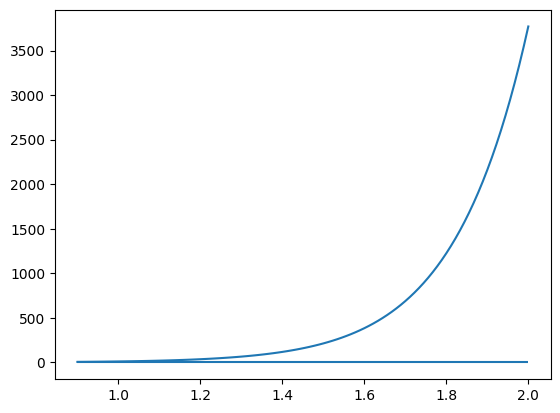

In [3]:
def func(x):
    return (1-(7*x**2-1)/x**2/8)*(1+(7*x**2-1)/8)**7-x**10

fig, ax1 = plt.subplots(1,1)
x = np.linspace(0.9,2,100)
ax1.plot(x,func(x))
ax1.hlines(0,x[0],x[-1])
plt.show()

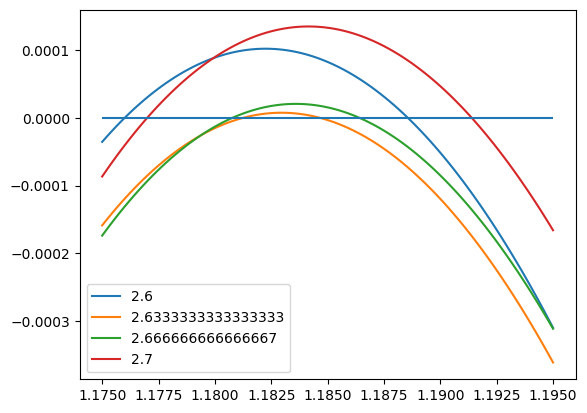

In [30]:
def func(r,phi):
    return np.cos(phi)-r**6/np.sqrt(1+r**2*np.sin(phi)**2)**7
fig, ax1 = plt.subplots(1,1)
phi = np.linspace(1.175,1.195,100)
# er = np.zeros((2,len(phi)))
# er[0,:] = np.cos(phi)
# er[1,:] = np.sin(phi)
r = np.linspace(2.6,2.7,4)


for i in range(len(r)):

    ax1.plot(phi,func(r[i],phi),label=f"{r[i]}")
ax1.hlines(0,phi[0],phi[-1])
ax1.legend()
plt.show()

      converged: True
           flag: converged
 function_calls: 44
     iterations: 22
           root: 2.6457512891338317
         method: newton


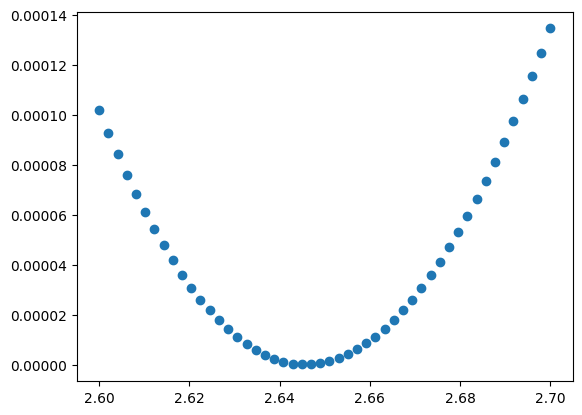

In [29]:
def func(y,r):
    x = y**2*r**2+1
    b = 7*r**8
    return x**9+b**2/r**2*x-b**2*(1+1/r**2)
from scipy.optimize import root_scalar
def rooty(r):
    rt = root_scalar(func,args=(r),x0=0.5)
    return rt.root
def maxi(r,x):
    return np.sqrt(1-x**2)-r**6/np.sqrt(1+r**2*x**2)**7
r = np.linspace(2.6,2.7)
roots = np.zeros_like(r)
maxima = np.zeros_like(r)
for i in range(len(r)):
    roots[i] = rooty(r[i])
    maxima[i] = maxi(r[i],roots[i])

def maximum(r):
    return maxi(r,rooty(r))
print(root_scalar(maximum,x0=2.6))
fig, ax = plt.subplots(1,1)
ax.scatter(r,maxima)
plt.show()


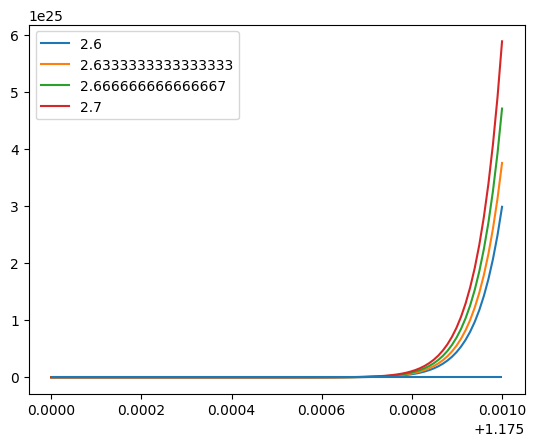

In [ ]:
def func(r,phi):
    return np.sin(phi)*np.cos(phi)/r**5-r*np.sin(phi)/np.sqrt(1+r**2*np.sin(phi)**2)**7
fig, ax1 = plt.subplots(1,1)
phi = np.linspace(1.175,1.176,100)
# er = np.zeros((2,len(phi)))
# er[0,:] = np.cos(phi)
# er[1,:] = np.sin(phi)
r = np.linspace(2.6,2.7,4)

def func(r,x):
    return x**9+7*r**6*x-7*r**8*(1+1/r**2)
for i in range(len(r)):
    x = np.linspace(0,10,100)**2*r[i]**2+1
    ax1.plot(phi,func(r[i],x),label=f"{r[i]}")
ax1.hlines(0,phi[0],phi[-1])
ax1.legend()
plt.show()

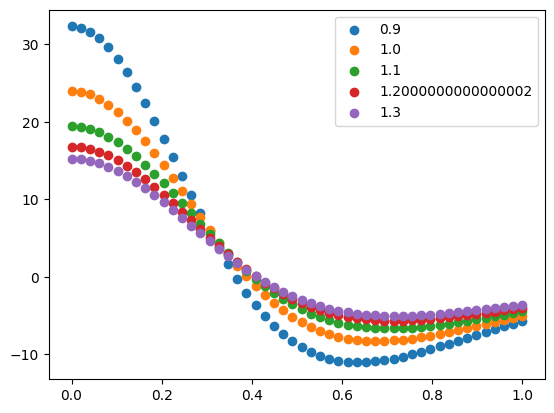

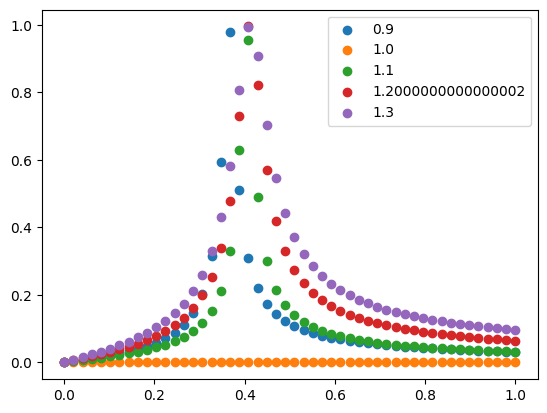

In [42]:
def d_1(a,e,d):
    r1 = np.sqrt(a**2+e**2)
    r2 = np.sqrt(1+e**2)
    A = 12*(1/r1**5+1/r2**5)-7*15*(a**2*e**2/r1**9+e**2/r2**9)
    B = 15*(a*e/r1**7-e/r2**7)
    res =  B**2*(1-d**2)/(A**2*d**2+B**2*(1-d**2))
    return A, B, np.sqrt(res)
fig, ax = plt.subplots(1,1)
fig2, ax2 = plt.subplots(1,1)
x = np.linspace(0,1)
alphas = np.linspace(0.9,1.3,5)
# alphas = [2.646]
d = 0.9
for i in range(len(alphas)):
    ax.scatter(x,d_1(alphas[i],x,d)[0],label=f"{alphas[i]}")
    ax2.scatter(x,d_1(alphas[i],x,d)[2],label=f"{alphas[i]}")
ax.legend()
ax2.legend()
plt.show()

0.11209940586114017
0.22938380978130846


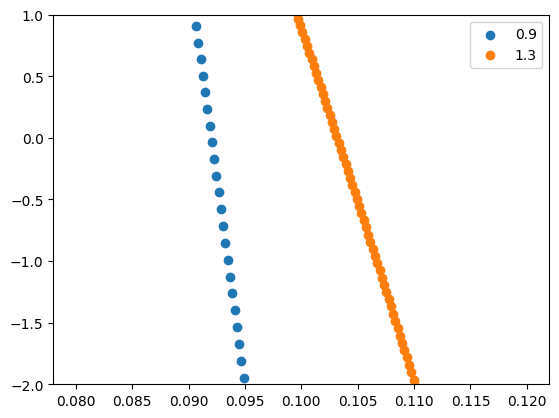

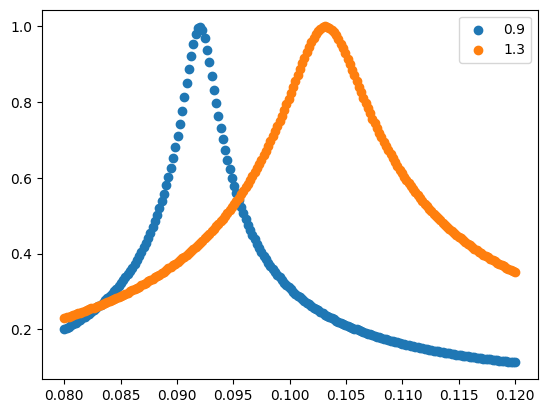

In [8]:
def func(e,a,d):
    r1 = np.sqrt(a**2+e**2)
    r2 = np.sqrt(1+e**2)
    A = 12*(1/r1**5+1/r2**5-7*15*(a**2*e**2/r1**9+e**2/r2**9))
    B = 15*(a*e/r1**7-e/r2**7)
    res1 = -B**2/2/(A**2-B**2)/d**2
    res2 = 1/2/(A**2-B**2)/d**2*np.sqrt(B**4-4*(A**2-B**2)*d**2*(d**2-1)*B**2)
    return A, B, res1+res2
fig, ax = plt.subplots(1,1)
fig2, ax2 = plt.subplots(1,1)
x = np.linspace(0.08,0.12,200)
alphas = np.linspace(0.9,1.3,2)
d = 0.5
for i in range(len(alphas)):
    ax.scatter(x,func(x,alphas[i],d)[0],label=f"{alphas[i]}")
    ax2.scatter(x,func(x,alphas[i],d)[2],label=f"{alphas[i]}")
    print(np.min(func(x,alphas[i],d)[2]))
ax.set_ylim(-2,1)
ax.legend()
ax2.legend()
plt.show()

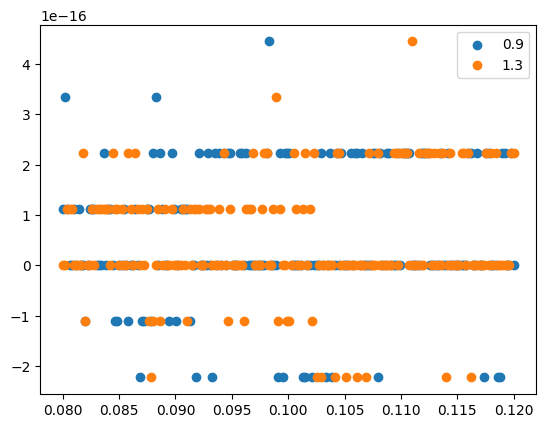

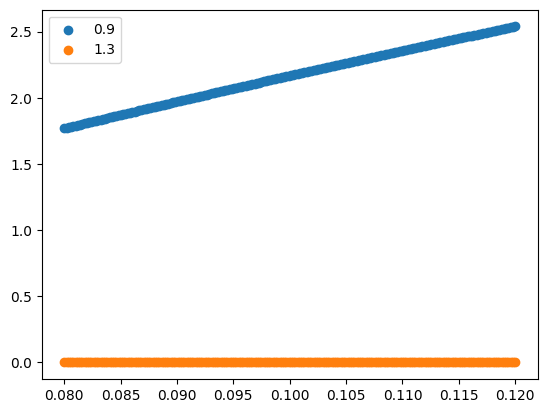

In [ ]:
def vxy1(alpha,e,d):
    A,B, d1 = d_1(alpha,e,d)
    return d1*d*A-np.sign(A*B)*B*np.sqrt(1-d1**2)*np.sqrt(1-d**2)
def vxy2(alpha,e,d):
    A,B, d1 = d_1(alpha,e,d)
    return d1*d*A+B*np.sqrt(1-d1**2)*np.sqrt(1-d**2)
fig, ax = plt.subplots(1,1)
fig2, ax2 = plt.subplots(1,1)
x = np.linspace(0.08,0.12,200)
alphas = np.linspace(0.9,1.3,2)
d = 0.5
for i in range(len(alphas)):
    ax.scatter(x,vxy1(alphas[i],x,d),label=f"{alphas[i]}")
    ax2.scatter(x,vxy2(alphas[i],x,d),label=f"{alphas[i]}")
    # ax2.scatter(x,vxy(alphas[i],d)[2],label=f"{alphas[i]}")
    # print(np.min(func(x,alphas[i],d)[1]))
# ax.set_ylim(-2,1)
ax.legend()
ax2.legend()
plt.show()

/tmp/ipykernel_9958/4115039790.py:53: RuntimeWarning: invalid value encountered in divide
  ax2[i//2,i%2].scatter(phi,np.arctan(yy/xx)+np.sign(yy)*np.pi*(1-np.sign(xx))/2,label=f"{alphas[i]}")


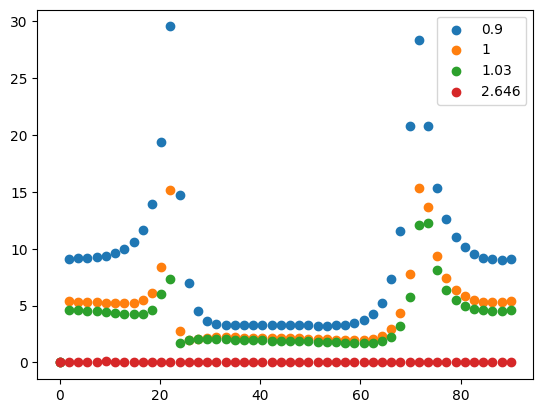

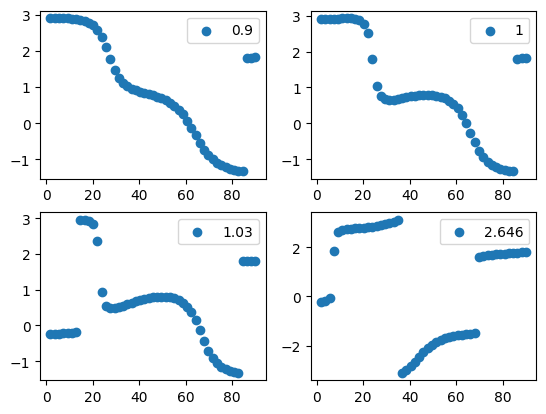

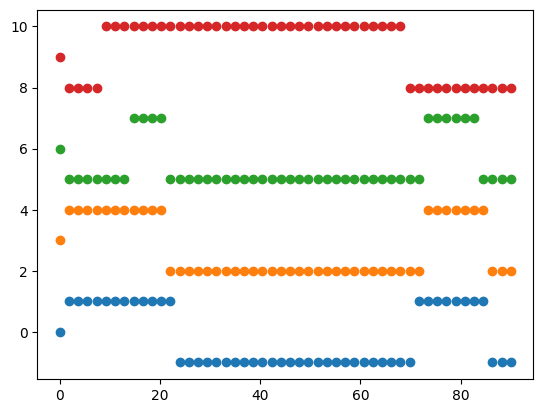

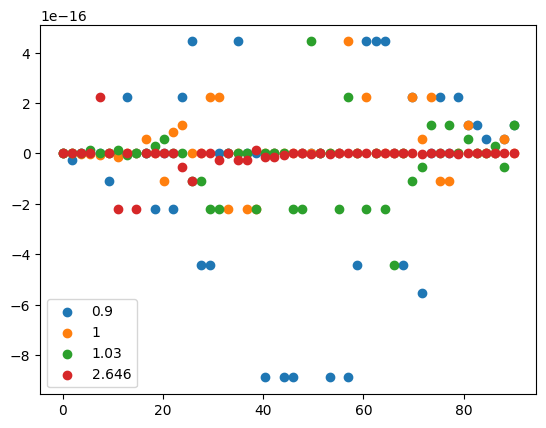

In [43]:
def interaction_rotated(DelR,i,j,d2,cut):
    r = np.sqrt(DelR[0]**2+DelR[1]**2)
    # if r ==0:
    #     return 0
    # if r>cut+0.01:
        # return 0
    Am, Bm, d1 = d_1(DelR[0],DelR[1],d2)
    if i==j:
        B = -3/r**5+15*DelR[i]**2/r**7
        A = 45*DelR[0]*DelR[1]/r**7-7*15*DelR[0]*DelR[1]*DelR[i]**2/r**9
        return A*d1*d2 -np.sign(Am*Bm)* B*np.sqrt(1-d1**2)*np.sqrt(1-d2**2)
    else:
        return d1*d2*Am-np.sign(Am*Bm)*Bm*np.sqrt(1-d1**2)*np.sqrt(1-d2**2)

def vxx(e,a,d):
    r1 = np.sqrt(a**2+e**2)
    r2 = np.sqrt(1+e**2)
    Am, Bm, d1 = d_1(a,e,d)
    A = 30*(a*e/r1**7-e/r2**7)-7*15*(a**3*e/r1**9-e/r2**9)
    B = -3*(1/r1**5+1/r2**5)+15*(a**2/r1**7+1/r2**7)
    res = A*d1*d-np.sign(Am*Bm)*B*np.sqrt(1-d1**2)*np.sqrt(1-d**2)
    return A, B, res

def vyy(e,a,d):
    r1 = np.sqrt(a**2+e**2)
    r2 = np.sqrt(1+e**2)
    Am, Bm, d1 = d_1(a,e,d)
    A = 30*(a*e/r1**7-e/r2**7)-7*15*(a*e**3/r1**9-e**3/r2**9)
    B = -3*(1/r1**5+1/r2**5)+15*(e**2/r1**7+e**2/r2**7)
    res = A*d1*d-np.sign(Am*Bm)*B*np.sqrt(1-d1**2)*np.sqrt(1-d**2)
    return np.sign(Bm*Am), res

fig, ax = plt.subplots(1,1)
# fig2, ax2 = plt.subplots(1,1)
fig2, ax2 = plt.subplots(2,2)
fig3, ax3 = plt.subplots(1,1)
fig4, ax4 = plt.subplots(1,1)
x = np.linspace(0.08,0.12)
# phi = np.linspace(0,np.pi/2)/np.pi*180
phi = np.linspace(0,90)
# alphas = np.linspace(0.9,1.3,4)
alphas = [0.9,1,1.03,2.646]
# alphas = [2.646]
d = 0.9

er = np.zeros((2,len(phi)))
er[0,:] = np.cos(phi/180*np.pi)
er[1,:] = np.sin(phi/180*np.pi)
for i in range(len(alphas)):
    yy = interaction_rotated(alphas[i]*er,1,1,d,100)
    xx = interaction_rotated(alphas[i]*er,0,0,d,100)
    ax.scatter(phi,np.sqrt(xx**2+yy**2),label=f"{alphas[i]}")
    ax2[i//2,i%2].scatter(phi,np.arctan(yy/xx)+np.sign(yy)*np.pi*(1-np.sign(xx))/2,label=f"{alphas[i]}")
    # ax2.scatter(phi,interaction_rotated(alphas[i]*er,0,0,d,100),label=f"{alphas[i]}")
    # ax.scatter(phi,xx,label=f"{alphas[i]}")
    # ax2.scatter(phi,yy,label=f"{alphas[i]}")
    # ax.scatter(x,vxx(alphas[i]*np.cos(phi),alphas[i]*np.sin(phi),d)[1],label=f"{alphas[i]}")
    # ax2.scatter(phi,vyy(alphas[i]*np.cos(phi),alphas[i]*np.sin(phi),d)[1],label=f"{alphas[i]}")
    ax2[i//2,i%2].legend()
    ax4.scatter(phi,interaction_rotated(alphas[i]*er,1,0,d,100),label=f"{alphas[i]}")
    ax3.scatter(phi,i*3+vyy(alphas[i]*np.sin(phi/180*np.pi),alphas[i]*np.cos(phi/180*np.pi),d)[0],label=f"{alphas[i]}")
ax.legend()
# ax2.legend()
# ax3.hlines(0,phi[0],phi[-1])
# ax3.legend()
ax4.legend()
plt.show()

0.9


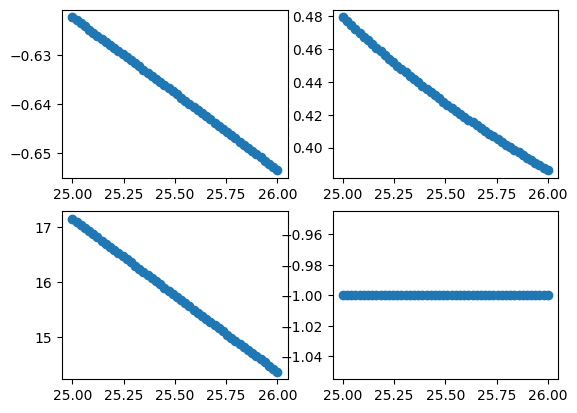

In [45]:



x = np.linspace(0.08,0.12)
# phi = np.linspace(0,np.pi/2)/np.pi*180
phi = np.linspace(25,26)
# alphas = np.linspace(0.9,1.3,4)
# alphas = [0.9,1,1.03,2.646]
alphas = [0.9]
# alphas = [2.646]
d = 0.9

er = np.zeros((2,len(phi)))
er[0,:] = -1#np.cos(phi/180*np.pi)
er[1,:] = np.sin(phi/180*np.pi)
for i in range(len(alphas)):
    fig2, ax2 = plt.subplots(2,2)
    print(alphas[i])
    yy = interaction_rotated(alphas[i]*er,1,1,d,100)
    xx = interaction_rotated(alphas[i]*er,0,0,d,100)
    ax2[1,0].scatter(phi,np.sqrt(xx**2+yy**2),label=f"{alphas[i]}")
    ax2[0,0].scatter(phi,np.arctan(yy/xx)+np.sign(yy)*np.pi*(1-np.sign(xx))/2)
    # ax2.scatter(phi,interaction_rotated(alphas[i]*er,0,0,d,100),label=f"{alphas[i]}")
    # ax.scatter(phi,xx,label=f"{alphas[i]}")
    # ax2.scatter(phi,yy,label=f"{alphas[i]}")
    # ax.scatter(x,vxx(alphas[i]*np.cos(phi),alphas[i]*np.sin(phi),d)[1],label=f"{alphas[i]}")
    # ax2.scatter(phi,vyy(alphas[i]*np.cos(phi),alphas[i]*np.sin(phi),d)[1],label=f"{alphas[i]}")
    # ax2[i//2,i%2].legend()
    ax2[0,1].scatter(phi,d_1(alphas[i]*np.cos(phi/180*np.pi),alphas[i]*np.sin(phi/180*np.pi),d)[2])
    if i==3:
        for j in range(4):
            # ax2[0,1].vlines(41.5,np.min(d_1(alphas[i]*np.sin(phi/180*np.pi),alphas[i]*np.cos(phi/180*np.pi),d)[2]),np.max(d_1(alphas[i]*np.sin(phi/180*np.pi),alphas[i]*np.cos(phi/180*np.pi),d)[2]))
            ax2[j//2,j%2].vlines(41.5,0,0.1,color='0')
    ax2[1,1].scatter(phi,i*3+vyy(alphas[i]*np.sin(phi/180*np.pi),alphas[i]*np.cos(phi/180*np.pi),d)[0],label=f"{alphas[i]}")
    plt.show()
# ax.legend()
# ax2.legend()
# ax3.hlines(0,phi[0],phi[-1])
# ax3.legend()
# ax4.legend()
plt.show()

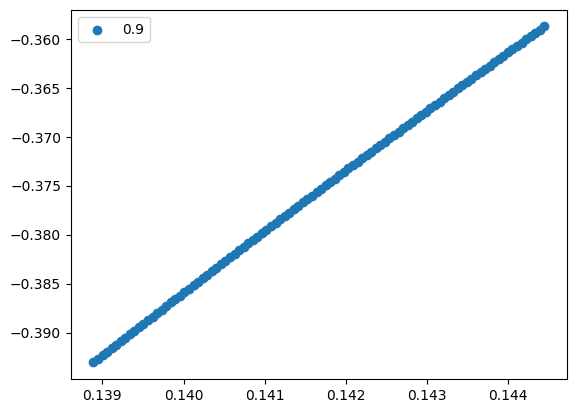

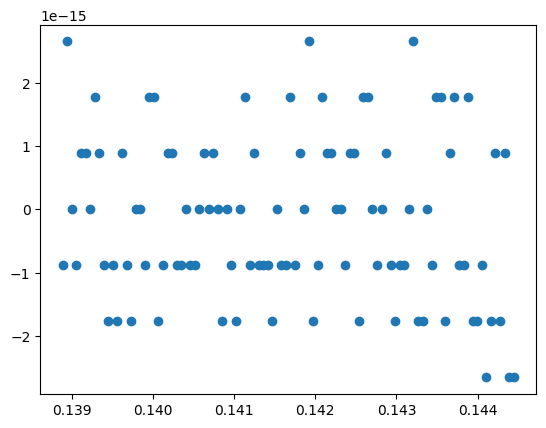

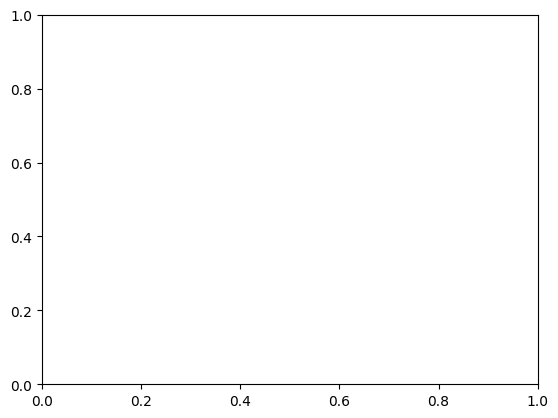

In [39]:



def phi_1(a,e):
    r1 = np.sqrt(a**2+e**2)
    r2 = np.sqrt(1+e**2)
    B = (12*(1/r1**5+1/r2**5)-7*15*(a**2*e**2/r1**9+e**2/r2**9))*(-1)
    A = 45*(a*e/r1**7-e/r2**7)-7*15*(a**3*e/r1**9-e/r2**9)
    res =  np.arctan(A/B)+np.where(B>=0,1,-1)*np.pi*(1-np.where(B>=0,1,-1))/2
    return res, -B*np.sin(res)+A*np.cos(res)

def interaction_dipplain(DelR,i,j,cut):
    r = np.sqrt(DelR[0]**2+DelR[1]**2)
    # if r ==0:
    #     return 0
    # if r>cut+0.01:
    #     return 0
    phi = phi_1(DelR[0],DelR[1])
    d = 0.9
    dx = np.cos(phi)*d
    dy = np.sin(phi)*d
    
    if i==j:
        A = -3/r**5+15*(DelR[0]**2+DelR[i]*DelR[0]*2+ DelR[i]**2)/r**7-7*15*DelR[0]**2*DelR[i]**2/r**9
        B = 15*DelR[0]*DelR[1]/r**7-7*15*DelR[0]*DelR[1]*DelR[i]**2/r**9
        if i==0:
            A += 15*2*DelR[0**2]/r**7-6/r**5
            B += 30*DelR[0]*DelR[1]/r**7
        return A*dx + B*dy
    else:
        B = 12/r**5-7*15*DelR[0]**2*DelR[1]**2/r**9
        A = 45*DelR[0]*DelR[1]/r**7-7*15*DelR[0]**3*DelR[1]/r**9
        return A*dx + B*dy

# plot the above with axis scaled in units of pi

fig, ax = plt.subplots(1,1)
fig2, ax2 = plt.subplots(1,1)
fig3, ax3 = plt.subplots(1,1)
# r = np.linspace(0.9,1.3,4)
r = [0.9]
phi = np.linspace(25,26,100)/180*np.pi
r1 = np.zeros((2,len(phi)))
r2 = np.zeros_like(r1)

for i in range(len(r)):  
    r1[0,:] = np.cos(phi)*r[i]
    r1[1,:] = np.sin(phi)*r[i]
    r2[0,:] = -1
    r2[1,:] = np.sin(phi)*r[i]       
    ax.scatter(phi/np.pi,phi_1(r[i]*np.cos(phi),r[i]*np.sin(phi))[0]/np.pi,label=f"{r[i]}")
    ax2.scatter(phi/np.pi,phi_1(r[i]*np.cos(phi),r[i]*np.sin(phi))[1],label=f"{r[i]}")
    # ax3.scatter(phi/np.pi,interaction_dipplain(r1,1,0,100)+interaction_dipplain(r2,1,0,100),label=f"{r[i]}")
ax.legend()
plt.show()


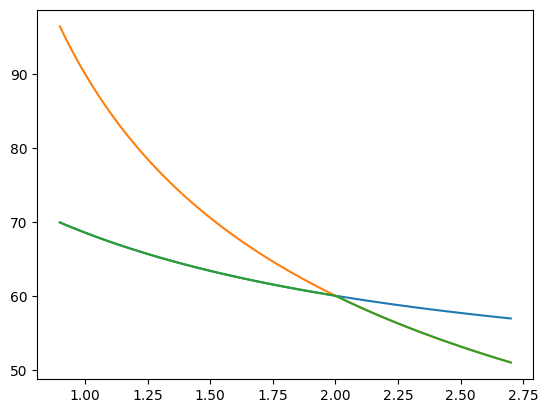

In [38]:
def fnc(r):
    return np.arccos((np.sqrt(1+2*r**2)-1)/2/r)/np.pi*180
def fnc2(r):
    return np.arccos((r-1)/r)/np.pi*180
def fnc3(r):
    return np.arcsin(np.sqrt(r**2-1)/r)/np.pi*180
def max_phi(r):
    return np.min(np.column_stack((np.arccos((np.sqrt(1+2*r**2)-1)/2/r)/np.pi*180,np.arccos((r-1)/r)/np.pi*180)),axis=1)
fig, ax = plt.subplots(1,1)
r = np.linspace(0.9,2.7,100)
ax.plot(r,fnc(r))
ax.plot(r,fnc2(r))
ax.plot(r,max_phi(r))
plt.show()

In [34]:
max_phi(r).shape

(100,)

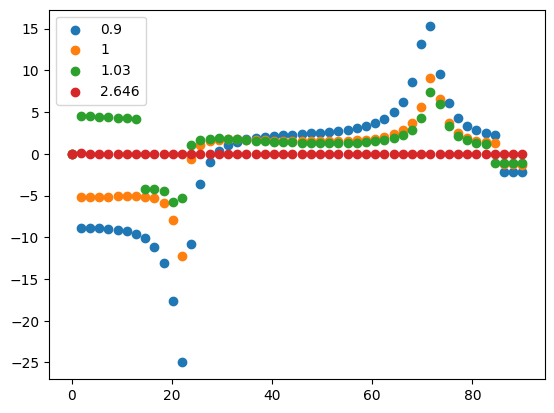

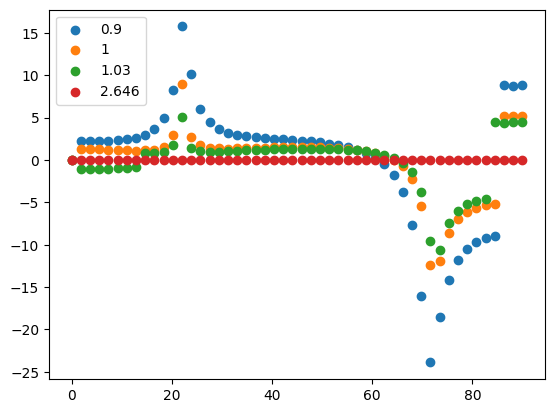

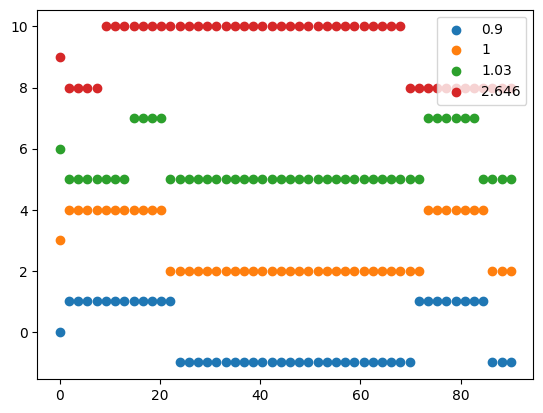

In [41]:
ig, ax = plt.subplots(1,1)
fig2, ax2 = plt.subplots(1,1)
fig3, ax3 = plt.subplots(1,1)
x = np.linspace(0.08,0.12)
# phi = np.linspace(0,np.pi/2)
# phi = np.linspace(65,90)
# alphas = np.linspace(0.9,1.3,4)
d = 0.9

er = np.zeros((2,len(phi)))
er[0,:] = np.cos(phi/180*np.pi)
er[1,:] = np.sin(phi/180*np.pi)
for i in range(len(alphas)):
    yy = interaction_rotated(alphas[i]*er,1,1,d,100)
    xx = interaction_rotated(alphas[i]*er,0,0,d,100)
    # ax.scatter(phi,np.sqrt(xx**2+yy**2),label=f"{alphas[i]}")
    # ax2[i//2,i%2].scatter(phi,np.arctan(yy/xx)+np.sign(yy)*np.pi*(1-np.sign(xx))/2,label=f"{alphas[i]}")
    # ax2.scatter(phi,interaction_rotated(alphas[i]*er,0,0,d,100),label=f"{alphas[i]}")
    ax.scatter(phi,xx,label=f"{alphas[i]}")
    ax2.scatter(phi,yy,label=f"{alphas[i]}")
    # ax.scatter(x,vxx(alphas[i]*np.cos(phi),alphas[i]*np.sin(phi),d)[1],label=f"{alphas[i]}")
    # ax2.scatter(phi,vyy(alphas[i]*np.cos(phi),alphas[i]*np.sin(phi),d)[1],label=f"{alphas[i]}")
    # ax2[i//2,i%2].legend()
    ax3.scatter(phi,i*3+vyy(alphas[i]*np.sin(phi/180*np.pi),alphas[i]*np.cos(phi/180*np.pi),d)[0],label=f"{alphas[i]}")
    # ax3.scatter(phi,i*3+vyy(alphas[i]*np.sin(phi/180*np.pi),alphas[i]*np.cos(phi/180*np.pi),d)[0],label=f"{alphas[i]}")
ax.legend()
ax2.legend()
ax3.legend()
plt.show()

In [23]:
def bloch(t,delta,omega):
    w = np.sqrt(delta**2/4+omega**2)
    N = w/omega*2
    z = 1/2*(1-4*omega**2/delta**2)/(1+4*omega**2/delta**2)*np.sin(w*t)**2+np.cos(w*t)**2/2
    x = -delta/omega/N**2*2*np.sin(w*t)**2
    y = -2/N*np.sin(w*t)*np.cos(w*t)
    return np.array([x,y,z])

def rot_ax(t,delta,omega):
    return 

delta = 1
omega= 0.2
T = 2*np.pi/np.sqrt(delta**2/4+omega**2)*4
t = np.linspace(0,T)
# plt.figure()
# plt.plot(t,np.linalg.norm(bloch(t,delta,omega),axis=1))
# plt.show()

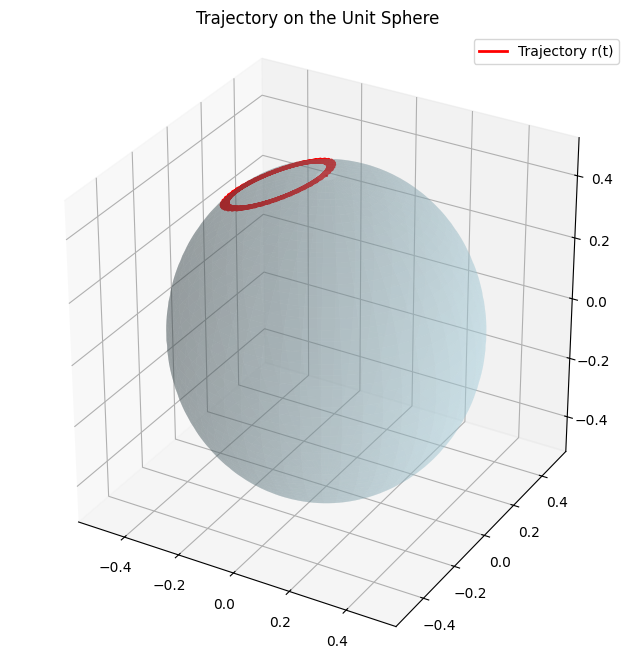

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Define trajectory on the unit sphere
def trajectory(t, alpha=0.2):
    x = np.cos(t) * np.sin(alpha * t)
    y = np.sin(t) * np.sin(alpha * t)
    z = np.cos(alpha * t)
    return x, y, z

# Create parameter t
# t = np.linspace(0, 20*np.pi, 2000)
x, y, z = bloch(t,delta,omega)

# Create sphere surface
radius = 0.5
phi, theta = np.mgrid[0:np.pi:100j, 0:2*np.pi:100j]
x_sphere = np.sin(phi) * np.cos(theta)*radius
y_sphere = np.sin(phi) * np.sin(theta)*radius
z_sphere = np.cos(phi)*radius

# Plot
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot sphere surface
ax.plot_surface(x_sphere, y_sphere, z_sphere, color='lightblue', alpha=0.3, linewidth=0)

# Plot trajectory
ax.plot(x, y, z, color='red', linewidth=2, label="Trajectory r(t)")

# Formatting
ax.set_box_aspect([1,1,1])
ax.set_title("Trajectory on the Unit Sphere")
ax.legend()
plt.show()


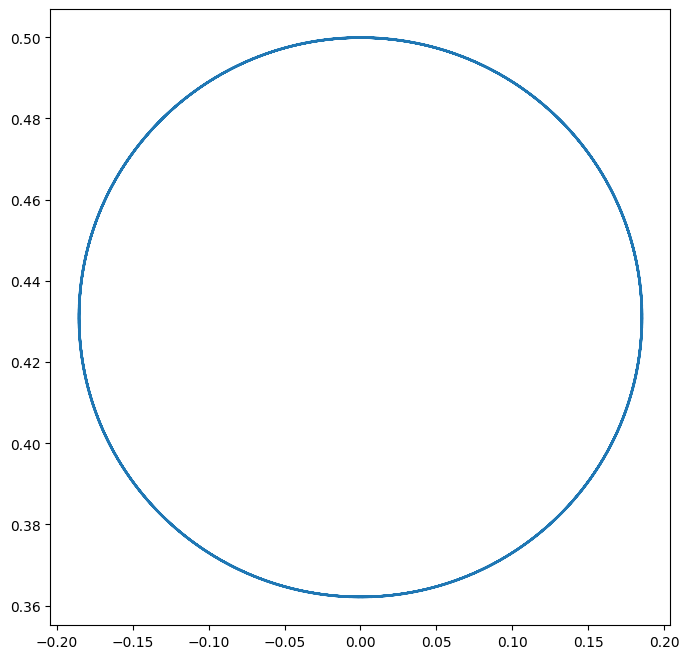

In [25]:
delta = 1
omega= 0.2
T = 2*np.pi/np.sqrt(delta**2/4+omega**2)*4
t = np.linspace(0,T,400)
x, y, z = bloch(t,delta,omega)

fig, ax = plt.subplots(1,1,figsize=(8,8))
ax.plot(y,z)
plt.show()

/home/christian/Documents/master/python_env/lib/python3.12/site-packages/scipy/integrate/_ivp/ivp.py:621: UserWarning: At least one element of `rtol` is too small. Setting `rtol = np.maximum(rtol, 2.220446049250313e-14)`.
  solver = method(fun, t0, y0, tf, vectorized=vectorized, **options)


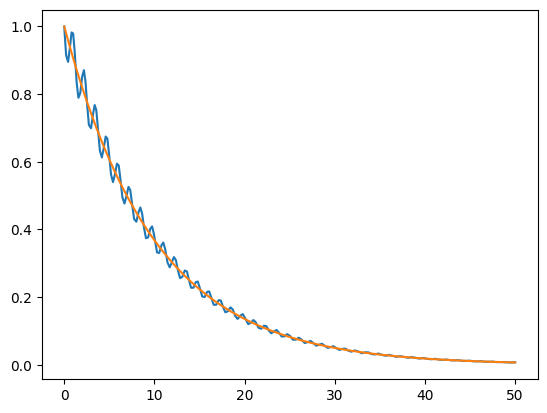

In [10]:
from scipy.integrate import solve_ivp
def kernel(t,x,A,B,w):
    dxdt = (-A-B*np.cos(w*t))*x
    return dxdt
a = 0.1
b = 4*a
w = 5
T= 5/a
sol = solve_ivp(kernel,[0,T],[1],args=(a,b,w),rtol=1e-15)
x = np.linspace(0,T,100)
plt.figure()
plt.plot(sol.t,sol.y[0])
plt.plot(x,np.exp(-a*x))
plt.show()